# Binary Modulation of V1 Responses

Running modulation of V1 responses across drifting gratings (DG), static gratings (SG), natural scenes (NS), and spontaneous activity, measured in 47 matched cells. Analysis code lives in `utils.py`; stimuli are extracted and analyzed separately and trials are never pooled across stimulus classes.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from utils import (
    STIMULI,
    SHORT_STIM,
    load_data,
    run_binary_modulation_analysis,
    summarize_binary_modulation_runs,
    summarize_gain_model,
    compare_gratings_vs_natural,
    validate_mi_against_metadata,
    plot_metric_comparison,
    plot_grating_natural_paired_scatter,
    plot_metadata_validation,
    plot_tuned_neurons_grid,
)

data = load_data("data")

RESPONSE_WINDOWS = {
    "drifting_gratings": (10, 60),
    "static_gratings": (5, 7),
    "natural_scenes": (5, 7),
    "spontaneous": (0, 60),
}

results = run_binary_modulation_analysis(
    data,
    RESPONSE_WINDOWS,
    run_threshold=3.0,
    still_threshold=0.5,
    min_trials_per_state=2,
    min_gain_conditions=3,
)
print("Matched cells:", len(data["matched_cell_ids"]))

Matched cells: 47


## 1. Data and metric definition

### 1.1 Trial classification

Each trial is assigned a behavioral state from its running-speed trace. Running trials have mean speed above 3.0 cm/s with every frame above 0.5 cm/s; still trials have mean speed below 0.5 cm/s with every frame below 3.0 cm/s; all remaining trials are ignored.

In [2]:
run_summary = summarize_binary_modulation_runs(results)
run_summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]]

,stimulus,n_trials,n_running,n_still,n_ignored
0,drifting_gratings,598,195,28,375
1,static_gratings,5811,1825,2722,1264
2,natural_scenes,5900,1315,2997,1588
3,spontaneous,296,44,26,226


Both states are populated in every stimulus, so the running-versus-still contrast is defined throughout. The balance is strongly skewed for DG, which retains only 28 still trials against 195 running trials, whereas SG and NS retain thousands of each. DG estimates therefore rest on far less still data than the other stimuli.

### 1.2 Metric definition

Because $\Delta F/F$ responses can be signed, we use the following modulation index:

$$
MI_i =
\frac{R_{\mathrm{run},i}-R_{\mathrm{still},i}}
{\left|R_{\mathrm{run},i}\right|
+\left|R_{\mathrm{still},i}\right|
+\epsilon}
$$

where $R_{\mathrm{run},i}$ and $R_{\mathrm{still},i}$ are the mean responses of cell $i$ across clean running and still trials, respectively, and $\epsilon$ is a small positive constant. This index is bounded in $[-1,1]$, and its sign agrees with the response difference $R_{\mathrm{run},i}-R_{\mathrm{still},i}$. It is stored in `binary.mi` and is the only MI used in the formal analysis.

We additionally report the unnormalized response difference

$$
\Delta R_i =
R_{\mathrm{run},i}-R_{\mathrm{still},i}
$$

which retains the original $\Delta F/F$ scale and is used as a denominator-free sensitivity measure. 

The original raw index,

$$
MI_{\mathrm{raw},i} =
\frac{R_{\mathrm{run},i}-R_{\mathrm{still},i}}
{R_{\mathrm{run},i}+R_{\mathrm{still},i}}
$$

can become unstable when its denominator is close to zero or negative. The corresponding metric comparison and diagnostics are documented separately in `MI_metric_audit.ipynb`.

## 2. Main scientific results

### 2.1 Sign-safe MI across stimuli

Population distributions of the sign-safe MI defined in Section 1.2 (bounded in [-1, 1]), together with its denominator-free sensitivity check delta_R = R_run - R_still, across all four conditions.

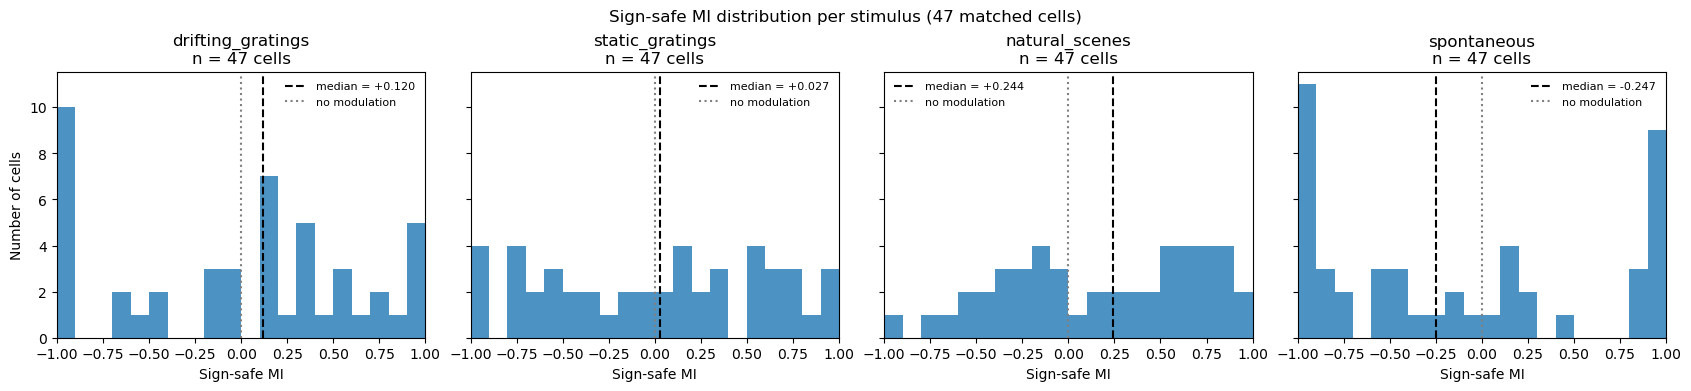

In [3]:
fig, axes = plot_metric_comparison(results, metric="mi")
for ax in axes:
    ax.set_xlabel("Sign-safe MI")
fig.suptitle("Sign-safe MI distribution per stimulus (47 matched cells)")
plt.show()

In [4]:
rows = []
for stimulus, a in results.items():
    mi = a.mi[np.isfinite(a.mi)]
    rows.append({
        "stimulus": stimulus,
        "n_cells": int(mi.size),
        "median_safe_mi": float(np.nanmedian(mi)),
        "fraction_positive_safe_mi": float(np.mean(mi > 0)),
    })
mi_safe_table = pd.DataFrame(rows)
mi_safe_table["direction"] = np.where(
    mi_safe_table["median_safe_mi"] > 0, "enhanced by running", "suppressed by running")
mi_safe_table

,stimulus,n_cells,median_safe_mi,fraction_positive_safe_mi,direction
0,drifting_gratings,47,0.120017,0.553191,enhanced by running
1,static_gratings,47,0.026739,0.531915,enhanced by running
2,natural_scenes,47,0.244089,0.574468,enhanced by running
3,spontaneous,47,-0.247195,0.425532,suppressed by running


Median sign-safe MI is positive for all three visually evoked stimuli and negative for spontaneous activity, so running is associated with enhanced evoked responses but suppressed no-stimulus activity. Natural scenes show the largest median modulation and static gratings the smallest. The effect is a population tendency rather than a universal one, since only 53 to 57 percent of cells are positive under evoked stimuli.

### 2.2 Gain analysis

The condition-level gain model fits 

$$
R_{\mathrm{run},c} = a \cdot R_{\mathrm{still},c} + b
$$

across stimulus conditions for each neuron, where a is the multiplicative slope, b is the additive offset, and R² measures how well one linear gain relation explains condition-level variation. A large slope does not imply a strong fit when R² is low, because the line can pass through a widely scattered cloud of conditions. Spontaneous activity has no condition structure and is excluded.

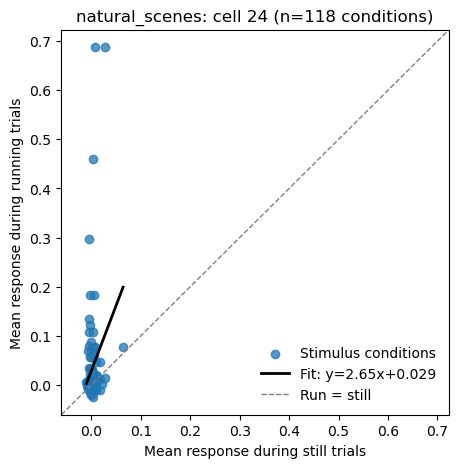

Example natural_scenes cell 24 (near-median gain-model R^2): a = 2.648, b = +0.0291, R^2 = 0.047 (population median R^2 = 0.047)


In [5]:
stimulus = "natural_scenes"
analysis = results[stimulus]

eligible_cells = np.where(analysis.gain_valid & (analysis.n_gain_conditions >= 10))[0]
population_median_r2 = np.nanmedian(analysis.gain_r2[analysis.gain_valid])
example_cell = int(
    eligible_cells[np.nanargmin(np.abs(analysis.gain_r2[eligible_cells] - population_median_r2))]
)

analysis.plot_scatter(cell=example_cell)
plt.show()

print(
    f"Example {stimulus} cell {example_cell} (near-median gain-model R^2): "
    f"a = {analysis.gain_a[example_cell]:.3f}, "
    f"b = {analysis.gain_b[example_cell]:+.4f}, "
    f"R^2 = {analysis.gain_r2[example_cell]:.3f} "
    f"(population median R^2 = {population_median_r2:.3f})"
)

In [6]:
summarize_gain_model(results)

,stimulus,n_valid_gain_fits,median_gain_a,median_gain_b,median_gain_r2,median_n_conditions,frac_gain_a_gt_1
0,drifting_gratings,47,0.109210,0.001252,0.107586,6.0,0.085106
1,static_gratings,47,0.273037,0.002341,0.053763,120.0,0.085106
2,natural_scenes,47,0.452296,0.009118,0.047038,118.0,0.234043


The example cell has a near-median gain-model R², and its fitted line is steep while its condition points scatter widely around it. Across the population, all 47 cells produced a valid fit for each visually evoked stimulus, but median R² is only 0.05 to 0.11, so a single linear gain explains little condition-level variation. Natural scenes have the largest fraction of slopes above one (23% vs 9% for DG and SG), which is a descriptive pattern consistent with their larger median MI, not evidence of a multiplicative modulation mechanism given how weak the fits are.

### 2.3 Gratings versus natural scenes

For each matched cell the grating value is the mean of its DG and SG sign-safe MI, compared against its natural-scenes sign-safe MI with a paired Wilcoxon signed-rank test.

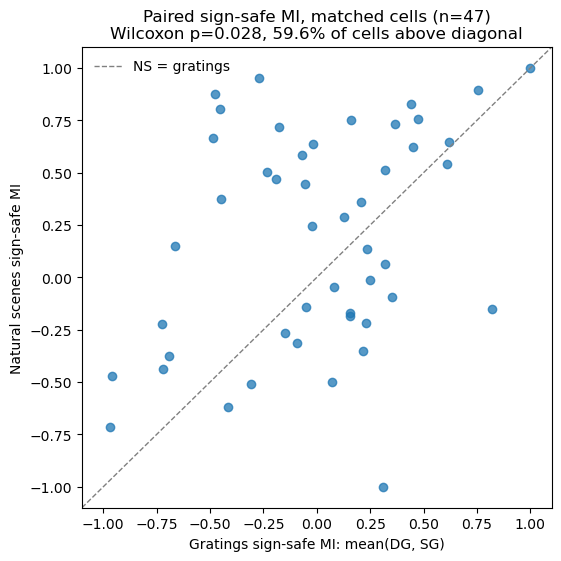

In [7]:
b6_result, _, grating_values, natural_values = compare_gratings_vs_natural(results)
p_value_mi = float(b6_result["p_value"].iloc[0])

fig, ax = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)
plot_grating_natural_paired_scatter(grating_values, natural_values, p_value=p_value_mi, ax=ax)
ax.set_xlabel("Gratings sign-safe MI: mean(DG, SG)")
ax.set_ylabel("Natural scenes sign-safe MI")
ax.set_title(
    f"Paired sign-safe MI, matched cells (n={len(grating_values)})\n"
    f"Wilcoxon p={p_value_mi:.3f}, "
    f"{100*float(b6_result['frac_NS_greater_than_grating'].iloc[0]):.1f}% of cells above diagonal"
)
plt.show()

In [8]:
delta_dg = results["drifting_gratings"].delta_r
delta_sg = results["static_gratings"].delta_r
delta_ns = results["natural_scenes"].delta_r
delta_grating = np.nanmean(np.vstack([delta_dg, delta_sg]), axis=0)
valid_delta = np.isfinite(delta_dg) & np.isfinite(delta_sg) & np.isfinite(delta_ns) & np.isfinite(delta_grating)
_, p_value_deltaR = wilcoxon(delta_grating[valid_delta], delta_ns[valid_delta])

def _direction(g, n):
    return "NS > gratings" if np.nanmedian(n) > np.nanmedian(g) else "gratings > NS"

b6_sensitivity = pd.DataFrame([
    {"metric": "Sign-safe MI", "n_cells": int(b6_result["n_cells"].iloc[0]),
     "direction": _direction(grating_values, natural_values),
     "p_value": round(p_value_mi, 3)},
    {"metric": "delta_R", "n_cells": int(valid_delta.sum()),
     "direction": _direction(delta_grating[valid_delta], delta_ns[valid_delta]),
     "p_value": round(float(p_value_deltaR), 3)},
])
b6_sensitivity

,metric,n_cells,direction,p_value
0,Sign-safe MI,47,NS > gratings,0.028
1,delta_R,47,NS > gratings,0.208


Both formal metrics agree in direction, with higher median modulation for natural scenes than for gratings, but only the sign-safe MI reaches nominal significance. The evidence is therefore suggestive rather than robust across metrics. The historical raw/robust MI comparison is kept for reference in `MI_metric_audit.ipynb`.

DG running and still trials cover different stimulus-condition sets, so aggregate DG modulation may partly reflect orientation or temporal-frequency tuning differences.

### 2.4 Allen validation

Sign-safe MI is compared against the Allen precomputed running-modulation indices `run_mod_dg`, `run_mod_sg`, and `run_mod_ns`, aligned by `cell_specimen_id` and correlated with Spearman rank correlation.

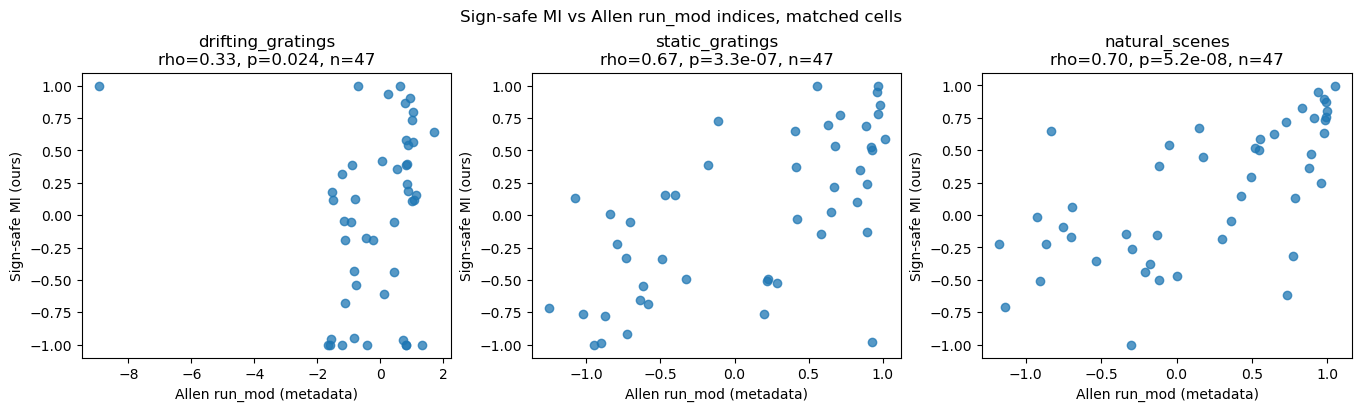

,stimulus,metadata_col,n_cells,spearman_rho,p_value
0,drifting_gratings,run_mod_dg,47,0.329093,2.390063e-02
1,static_gratings,run_mod_sg,47,0.665934,3.251418e-07
2,natural_scenes,run_mod_ns,47,0.697155,5.205690e-08


In [9]:
metadata = pd.read_csv("data/neurons_metadata.csv")

validation_df, aligned = validate_mi_against_metadata(
    results, metadata, data["matched_cell_ids"],
)

fig, axes = plot_metadata_validation(aligned, validation_df, ylabel="Sign-safe MI (ours)")
fig.suptitle("Sign-safe MI vs Allen run_mod indices, matched cells")
plt.show()

validation_df[["stimulus", "metadata_col", "n_cells", "spearman_rho", "p_value"]]

Agreement with the Allen running-modulation indices is strong for SG and NS and weaker for DG. The DG result should be interpreted cautiously because of its stimulus-condition imbalance.

## 3. Final conclusion

We compared locomotion-related modulation across spontaneous activity and three visual stimuli using the sign-safe MI,

$$
MI =
\frac{R_{\mathrm{run}}-R_{\mathrm{still}}}
{|R_{\mathrm{run}}|+|R_{\mathrm{still}}|+\epsilon}
$$

together with the unnormalized response difference

$$
\Delta R =
R_{\mathrm{run}}-R_{\mathrm{still}}
$$

and a condition-level gain model,

$$
R_{\mathrm{run},c}
=
aR_{\mathrm{still},c}+b.
$$

1. **Visually evoked responses were generally higher during running, while spontaneous activity showed the opposite pattern.** Median MI was positive for DG, SG, and NS (0.12, 0.03, and 0.24) and negative for spontaneous activity (-0.25).

2. **Natural scenes showed the largest median modulation.** The difference between natural scenes and gratings was significant for MI ($p=0.028$), but not for $\Delta R$ ($p=0.208$), so this result depends on the chosen metric.

3. **The linear gain model explained little of the condition-level variation.** Median slopes were 0.11 for DG, 0.27 for SG, and 0.45 for NS, but median $R^2$ values were only 0.05–0.11. Natural scenes had more slopes above one, but the weak fits do not support a clear multiplicative mechanism.

4. **Agreement with the Allen running-modulation indices was stronger for SG and NS than for DG.** Spearman correlations were 0.67 for SG, 0.70 for NS, and 0.33 for DG. The DG estimate should be interpreted cautiously because still trials were fewer and running and still trials were unevenly distributed across stimulus conditions.

Overall, locomotion was associated with positive population-level modulation during visual stimulation and negative modulation during spontaneous activity. Per-neuron significance and speed tuning will be examined in Section 4, while additive and multiplicative effects will be tested more formally with the encoding model.

## 4. Speed tuning within modulated neurons

Section 4.1 defines a stimulus-specific `tuned_mask` via a condition-aware paired t-test on $R_{\mathrm{run},c} - R_{\mathrm{still},c}$ (matched by stimulus condition, see Section 2.2), and compares it against the Allen metadata's own per-stimulus significance test. Speed tuning, MI, and gain-model parameters within these modulated neurons (Sections 4.2-4.4) are not yet implemented.

### 4.1 Stimulus-specific modulated-cell masks

For each cell and stimulus, a one-sample t-test on the per-condition differences `condition_run - condition_still` (built by the gain model in Section 2.2) tests whether running significantly shifts the response, controlling for stimulus-condition identity: if running and still trials cover different sets of stimulus conditions, the pairing cancels that out, whereas a pooled trial-level test would confound stimulus tuning with speed tuning. Cells with $p < 0.05$ are flagged in `tuned_mask`. Spontaneous activity has no condition structure, so no cell is ever flagged for it. The computed mask is compared against the Allen metadata's own per-stimulus significance test (`p_run_mod_*` columns).

In [10]:
for analysis in results.values():
    analysis.compute_running_ttest()

for stimulus in STIMULI:
    print("=========", stimulus, "==========")
    results[stimulus].print_tuned_cells()

========= drifting_gratings ==========
Significantly tuned neurons: #4 
 [ 0 28 33 39]
  Cell 0: p = 0.02785
  Cell 28: p = 0.04694
  Cell 33: p = 0.01137
  Cell 39: p = 0.01933
========= static_gratings ==========
Significantly tuned neurons: #27 
 [ 0  1  4  6  9 11 13 14 15 16 17 20 21 23 25 27 28 29 30 36 37 38 40 43
 44 45 46]
  Cell 0: p = 0.04139
  Cell 1: p = 0.00014
  Cell 4: p = 0.00000
  Cell 6: p = 0.00034
  Cell 9: p = 0.03720
  Cell 11: p = 0.01176
  Cell 13: p = 0.00149
  Cell 14: p = 0.04994
  Cell 15: p = 0.00000
  Cell 16: p = 0.00000
  Cell 17: p = 0.00003
  Cell 20: p = 0.00041
  Cell 21: p = 0.00000
  Cell 23: p = 0.00020
  Cell 25: p = 0.00000
  Cell 27: p = 0.00299
  Cell 28: p = 0.00004
  Cell 29: p = 0.00000
  Cell 30: p = 0.00000
  Cell 36: p = 0.00002
  Cell 37: p = 0.00000
  Cell 38: p = 0.00002
  Cell 40: p = 0.01880
  Cell 43: p = 0.00083
  Cell 44: p = 0.00001
  Cell 45: p = 0.00413
  Cell 46: p = 0.00108
========= natural_scenes ==========
Significantly 

In [11]:
p_speed = metadata[[f"p_run_mod_{stim}" for stim in SHORT_STIM[:-1]]].values
mask_speed_tuned = p_speed < 0.05
speed_tuned = {stim: np.where(mask_speed_tuned[:, i])[0] for i, stim in enumerate(SHORT_STIM[:-1])}

tuned_neurons = {short: np.where(results[stim].tuned_mask)[0] for short, stim in zip(SHORT_STIM, STIMULI)}

for stim in SHORT_STIM[:-1]:
    computed_neurons = tuned_neurons[stim]
    metadata_neurons = speed_tuned[stim]
    shared_neurons = np.intersect1d(computed_neurons, metadata_neurons)
    print(f"{stim}: computed={len(computed_neurons)}, metadata={len(metadata_neurons)}, shared={len(shared_neurons)}")

dg: computed=4, metadata=7, shared=1
sg: computed=27, metadata=6, shared=3
ns: computed=29, metadata=15, shared=11


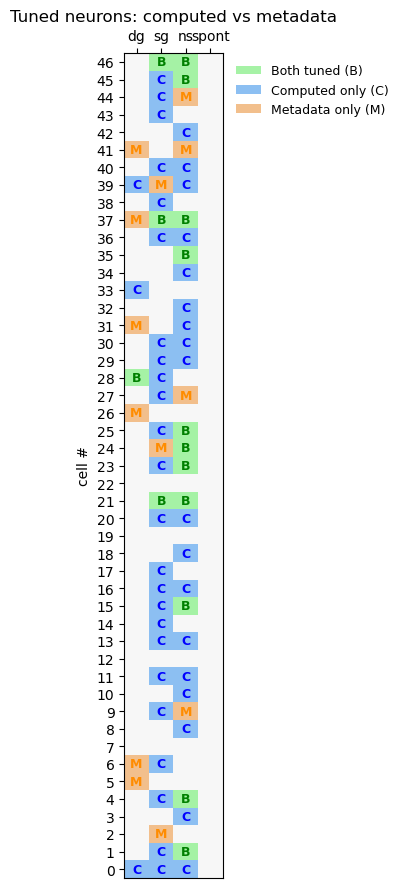

In [12]:
tuned_masks = {short: results[stim].tuned_mask for short, stim in zip(SHORT_STIM, STIMULI)}
speed_tuned_masks = {
    stim: np.isin(np.arange(len(data["matched_cell_ids"])), speed_tuned[stim])
    for stim in SHORT_STIM[:-1]  # spontaneous has no metadata significance test
}

fig = plot_tuned_neurons_grid(tuned_masks, metadata_tuned=speed_tuned_masks, figsize=(3.5, 9))
plt.show()

The computed and metadata-based tuned-cell sets agree only partially: 1 of 4 DG-computed cells, 3 of 27 SG-computed cells, and 11 of 29 NS-computed cells overlap with the corresponding metadata set. The computed test also flags a different number of cells per stimulus than the metadata test (DG: 4 vs 7, SG: 27 vs 6, NS: 29 vs 15), so the two tests are not interchangeable; they likely differ in trial-classification thresholds, condition definitions, or multiple-comparison handling. No multiple-comparisons correction (e.g. FDR) is applied here, so `tuned_mask` should be read as an uncorrected per-cell screen, not a final significance claim.

### 4.2 Speed tuning within modulated cells

### 4.3 MI and monotonicity

### 4.4 Gain parameters and tuning type